# NBA Player Clustering Analysis

**Author:** Dany Drammeh  
**Date:** April 3rd 2026  
**Data Source:** NBA Stats API

## Import Libraries

In [85]:
import requests
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [64]:
# Install nba_api if not already installed
!pip install nba_api

## Collect NBA Player Data

In [65]:
from nba_api.stats.endpoints import leaguedashplayerstats

# Fetch player stats
stats = leaguedashplayerstats.LeagueDashPlayerStats(
    season='2023-24',
    per_mode_detailed='PerGame',
    season_type_all_star='Regular Season'
)

# Convert to DataFrame
df = stats.get_data_frames()[0]
print(f"Total players: {len(df)}")

Total players: 572


## Explore the Dataset

In [66]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few players:")
df[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'MIN', 'PTS', 'REB', 'AST']].head(10)

Dataset shape: (572, 67)

Column names:
['PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT']

First few players:


,PLAYER_NAME,TEAM_ABBREVIATION,GP,MIN,PTS,REB,AST
0,A.J. Lawson,DAL,42,7.4,3.2,1.2,0.5
1,AJ Green,MIL,56,11.0,4.5,1.1,0.5
2,AJ Griffin,ATL,20,8.5,2.4,0.9,0.3
3,Aaron Gordon,DEN,73,31.5,13.9,6.5,3.5
4,Aaron Holiday,HOU,78,16.3,6.6,1.6,1.8
5,Aaron Nesmith,IND,72,27.7,12.2,3.8,1.5
6,Aaron Wiggins,OKC,78,15.7,6.9,2.4,1.1
7,Adam Flagler,OKC,2,7.0,1.5,0.0,2.0
8,Adama Sanogo,CHI,9,7.3,4.0,4.0,0.0
9,Admiral Schofield,ORL,23,3.7,1.1,0.7,0.3


## Data Cleaning and Filtering

In [67]:
# Filter to players with significant playing time
# Minimum 20 games played and 15 minutes per game
MIN_GAMES = 20
MIN_MINUTES = 15

df_filtered = df[
    (df['GP'] >= MIN_GAMES) &
    (df['MIN'] >= MIN_MINUTES)
].copy()

print(f"Players before filtering: {len(df)}")
print(f"Players after filtering (GP≥{MIN_GAMES}, MIN≥{MIN_MINUTES}): {len(df_filtered)}")
print(f"Removed: {len(df) - len(df_filtered)} players with limited playing time")

Players before filtering: 572
Players after filtering (GP≥20, MIN≥15): 316
Removed: 256 players with limited playing time


In [68]:
# Remove any rows with missing values in key stats
df_clean = df_filtered.dropna()

## Select Features for Clustering

In [69]:
# Select relevant statistical features
feature_cols = [
    'PTS',      # Points per game
    'REB',      # Rebounds per game
    'AST',      # Assists per game
    'STL',      # Steals per game
    'BLK',      # Blocks per game
    'FG3M',     # 3-pointers made per game
    'FG3A',     # 3-pointers attempted per game
    'FG_PCT',   # Field goal percentage
    'FT_PCT',   # Free throw percentage
    'TOV',      # Turnovers per game
    'MIN'       # Minutes per game
]

# Display feature statistics
df_clean[feature_cols].describe().round(2)

,PTS,REB,AST,STL,BLK,FG3M,FG3A,FG_PCT,FT_PCT,TOV,MIN
count,316.00,316.00,316.00,316.00,316.00,316.00,316.00,316.00,316.00,316.00,316.00
mean,12.51,4.62,2.93,0.81,0.54,1.41,3.82,0.48,0.78,1.42,25.86
std,6.43,2.36,1.97,0.34,0.46,0.90,2.30,0.07,0.09,0.78,6.37
min,1.70,1.10,0.50,0.20,0.00,0.00,0.00,0.34,0.41,0.30,15.00
25%,7.30,3.00,1.38,0.60,0.20,0.70,2.20,0.44,0.73,0.80,20.00
50%,10.90,4.00,2.35,0.80,0.40,1.30,3.60,0.46,0.79,1.20,26.40
75%,16.20,5.50,4.03,1.00,0.70,2.00,5.30,0.50,0.84,1.80,31.52
max,34.70,13.70,10.90,2.10,3.60,4.80,11.80,0.75,1.00,4.40,37.80


In [70]:
# Check for any infinite or NaN values after filtering
for col in feature_cols:
    if df_clean[col].isnull().any():
        print(f"Warning: {col} has NaN values")
    if np.isinf(df_clean[col]).any():
        print(f"Warning: {col} has infinite values")

# Fill any percentage NaN with 0 (players who didn't attempt shots)
df_clean['FG_PCT'] = df_clean['FG_PCT'].fillna(0)
df_clean['FT_PCT'] = df_clean['FT_PCT'].fillna(0)

## Feature Scaling (Standardization)

In [71]:
# Extract features
X = df_clean[feature_cols].values

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K Selection - Elbow Method

In [72]:
# Test different k values
k_range = range(2, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"  k={k}: inertia={kmeans.inertia_:.2f}")

  k=2: inertia=2421.78
  k=3: inertia=1948.97
  k=4: inertia=1735.06
  k=5: inertia=1558.14
  k=6: inertia=1461.85
  k=7: inertia=1375.57
  k=8: inertia=1305.17
  k=9: inertia=1233.81
  k=10: inertia=1171.32


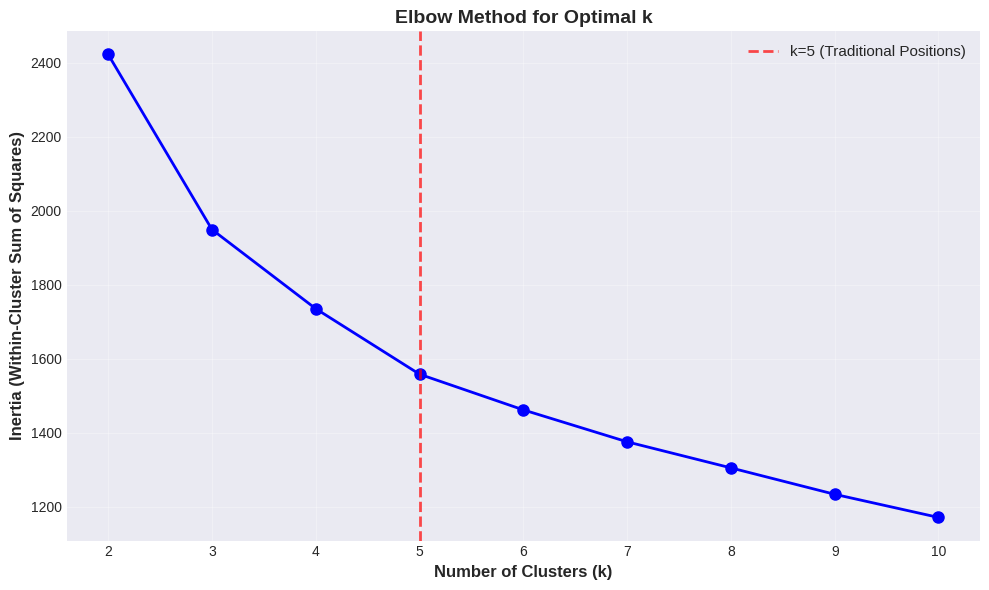

In [73]:
# Plot elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)

# Highlight k=5 (traditional positions)
ax.axvline(x=5, color='red', linestyle='--', linewidth=2, alpha=0.7,
           label='k=5 (Traditional Positions)')

ax.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
ax.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_range)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


## K Selection - Silhouette Score

In [74]:
# Compute silhouette scores
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"  k={k}: silhouette={score:.4f}")

# Find best k
best_k = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"\n✓ Best k by silhouette score: {best_k} (score={best_score:.4f})")
print(f"  Traditional positions would suggest k=5")

  k=2: silhouette=0.2774
  k=3: silhouette=0.2833
  k=4: silhouette=0.1962
  k=5: silhouette=0.1960
  k=6: silhouette=0.1638
  k=7: silhouette=0.1725
  k=8: silhouette=0.1652
  k=9: silhouette=0.1653
  k=10: silhouette=0.1666

✓ Best k by silhouette score: 3 (score=0.2833)
  Traditional positions would suggest k=5


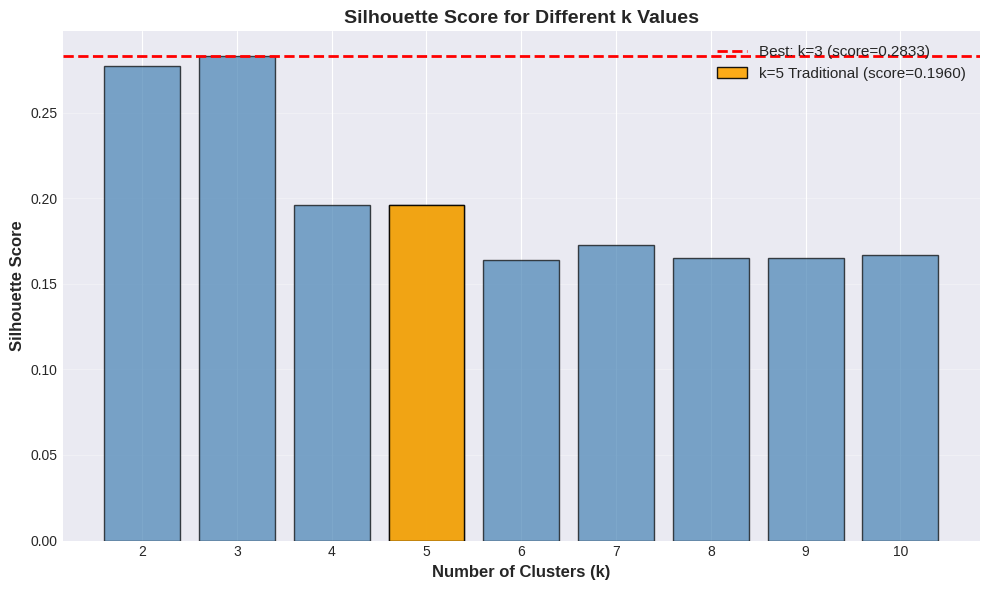

In [75]:
# Plot silhouette scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(k_range, silhouette_scores, color='steelblue', edgecolor='black', alpha=0.7)
ax.axhline(y=best_score, color='red', linestyle='--', linewidth=2,
           label=f'Best: k={best_k} (score={best_score:.4f})')

# Highlight k=5
if 5 in k_range:
    idx_5 = list(k_range).index(5)
    ax.bar(5, silhouette_scores[idx_5], color='orange', edgecolor='black', alpha=0.9,
           label=f'k=5 Traditional (score={silhouette_scores[idx_5]:.4f})')

ax.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax.set_title('Silhouette Score for Different k Values', fontsize=14, fontweight='bold')
ax.set_xticks(k_range)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Final K-Means Clustering

In [76]:
# Use best k from silhouette OR compare k=5 vs best_k
# Let's use the best k from silhouette analysis
FINAL_K = best_k

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_clean['cluster'] = cluster_labels

# Calculate cluster statistics
cluster_counts = df_clean['cluster'].value_counts().sort_index()

print(f"\nCluster sizes:")
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} players ({count/len(df_clean)*100:.1f}%)")


Cluster sizes:
  Cluster 0: 161 players (50.9%)
  Cluster 1: 106 players (33.5%)
  Cluster 2: 49 players (15.5%)


## Cluster Quality Metrics

In [77]:
# Calculate quality metrics
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_inertia = kmeans_final.inertia_
davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)

print("Cluster Quality Metrics:")
print(f"  Silhouette Score: {final_silhouette:.4f} (higher is better, range: -1 to 1)")
print(f"  Inertia: {final_inertia:.2f} (lower is better)")
print(f"  Davies-Bouldin Index: {davies_bouldin:.4f} (lower is better)")

Cluster Quality Metrics:
  Silhouette Score: 0.2833 (higher is better, range: -1 to 1)
  Inertia: 1948.97 (lower is better)
  Davies-Bouldin Index: 1.2722 (lower is better)


## Cluster Characterization

In [78]:
# Calculate mean features per cluster
cluster_profiles = df_clean.groupby('cluster')[feature_cols].mean()

print("Cluster Feature Profiles:")
print(cluster_profiles.round(2))

Cluster Feature Profiles:
           PTS   REB   AST   STL   BLK  FG3M  FG3A  FG_PCT  FT_PCT   TOV  \
cluster                                                                    
0         8.39  3.35  2.01  0.69  0.37  1.20  3.26    0.45    0.78  0.97   
1        19.06  5.03  4.65  1.03  0.52  2.23  5.96    0.46    0.83  2.11   
2        11.88  7.90  2.20  0.73  1.19  0.34  1.02    0.58    0.69  1.45   

           MIN  
cluster         
0        21.82  
1        32.32  
2        25.17  


In [79]:
# Characterize each cluster based on dominant stats
def characterize_player_cluster(cluster_id, profile):
    characteristics = []
    archetype = ""

    # Scoring
    if profile['PTS'] > 20:
        characteristics.append('High Scorer')
    elif profile['PTS'] < 10:
        characteristics.append('Role Player')

    # Playmaking
    if profile['AST'] > 5:
        characteristics.append('Playmaker')
        if profile['PTS'] > 18:
            archetype = "Primary Ball Handler (Modern PG/Combo Guard)"
        else:
            archetype = "Traditional Point Guard"

    # Rebounding
    if profile['REB'] > 8:
        characteristics.append('Strong Rebounder')
        if profile['BLK'] > 1:
            archetype = "Traditional Center/Big"
        elif profile['FG3M'] > 1:
            archetype = "Stretch Big/Modern Forward"

    # Three-point shooting
    if profile['FG3M'] > 2:
        characteristics.append('Three-Point Shooter')

    # Defense
    if profile['BLK'] > 1:
        characteristics.append('Rim Protector')
    if profile['STL'] > 1:
        characteristics.append('Perimeter Defender')

    # Wing player
    if profile['PTS'] > 15 and profile['REB'] > 4 and profile['AST'] > 3:
        archetype = "Versatile Wing (Modern 3&D or Point Forward)"

    # Catch and shoot
    if profile['FG3M'] > 2 and profile['AST'] < 3 and profile['PTS'] < 15:
        archetype = "3&D Specialist/Role Player"

    if not archetype:
        archetype = "Balanced/Hybrid Role"

    return archetype, characteristics

# Characterize each cluster
for cluster_id in range(FINAL_K):
    profile = cluster_profiles.loc[cluster_id]
    archetype, chars = characterize_player_cluster(cluster_id, profile)

    print(f"\nCluster {cluster_id}: {archetype}")
    print(f"  Characteristics: {', '.join(chars) if chars else 'Balanced'}")
    print(f"  Key stats: PTS={profile['PTS']:.1f}, REB={profile['REB']:.1f}, AST={profile['AST']:.1f}")
    print(f"  3PM={profile['FG3M']:.1f}, BLK={profile['BLK']:.1f}, STL={profile['STL']:.1f}")


Cluster 0: Balanced/Hybrid Role
  Characteristics: Role Player
  Key stats: PTS=8.4, REB=3.4, AST=2.0
  3PM=1.2, BLK=0.4, STL=0.7

Cluster 1: Versatile Wing (Modern 3&D or Point Forward)
  Characteristics: Three-Point Shooter, Perimeter Defender
  Key stats: PTS=19.1, REB=5.0, AST=4.7
  3PM=2.2, BLK=0.5, STL=1.0

Cluster 2: Balanced/Hybrid Role
  Characteristics: Rim Protector
  Key stats: PTS=11.9, REB=7.9, AST=2.2
  3PM=0.3, BLK=1.2, STL=0.7


## Example Players Per Cluster

In [80]:
# Get example players per cluster (sorted by minutes played - most impactful)
print("\nExample Players Per Cluster:")

for cluster_id in range(FINAL_K):
    cluster_players = df_clean[df_clean['cluster'] == cluster_id].sort_values(
        'MIN', ascending=False
    ).head(10)

    print(f"\nCluster {cluster_id} ({len(df_clean[df_clean['cluster'] == cluster_id])} players):")
    for idx, row in cluster_players.iterrows():
        print(f"  • {row['PLAYER_NAME']:30s} ({row['TEAM_ABBREVIATION']:3s}) - "
              f"PTS:{row['PTS']:4.1f} REB:{row['REB']:4.1f} AST:{row['AST']:4.1f}")


Example Players Per Cluster:

Cluster 0 (161 players):
  • Kentavious Caldwell-Pope       (DEN) - PTS:10.1 REB: 2.4 AST: 2.4
  • Dillon Brooks                  (HOU) - PTS:12.7 REB: 3.4 AST: 1.7
  • Isaiah Stewart                 (DET) - PTS:10.9 REB: 6.6 AST: 1.6
  • Jeremy Sochan                  (SAS) - PTS:11.6 REB: 6.4 AST: 3.4
  • Malik Beasley                  (MIL) - PTS:11.3 REB: 3.7 AST: 1.4
  • Jaden McDaniels                (MIN) - PTS:10.5 REB: 3.1 AST: 1.4
  • Ayo Dosunmu                    (CHI) - PTS:12.2 REB: 2.8 AST: 3.2
  • Harrison Barnes                (SAC) - PTS:12.2 REB: 3.0 AST: 1.2
  • Dorian Finney-Smith            (BKN) - PTS: 8.5 REB: 4.7 AST: 1.6
  • Luguentz Dort                  (OKC) - PTS:10.9 REB: 3.6 AST: 1.4

Cluster 1 (106 players):
  • DeMar DeRozan                  (CHI) - PTS:24.0 REB: 4.3 AST: 5.3
  • Luka Dončić                    (DAL) - PTS:33.9 REB: 9.2 AST: 9.8
  • Tyrese Maxey                   (PHI) - PTS:25.9 REB: 3.7 AST: 6.2
  • Mile

## Visualization - PCA Projection

In [81]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

PCA explained variance: [0.43173835 0.26834375]
Total variance explained: 70.01%


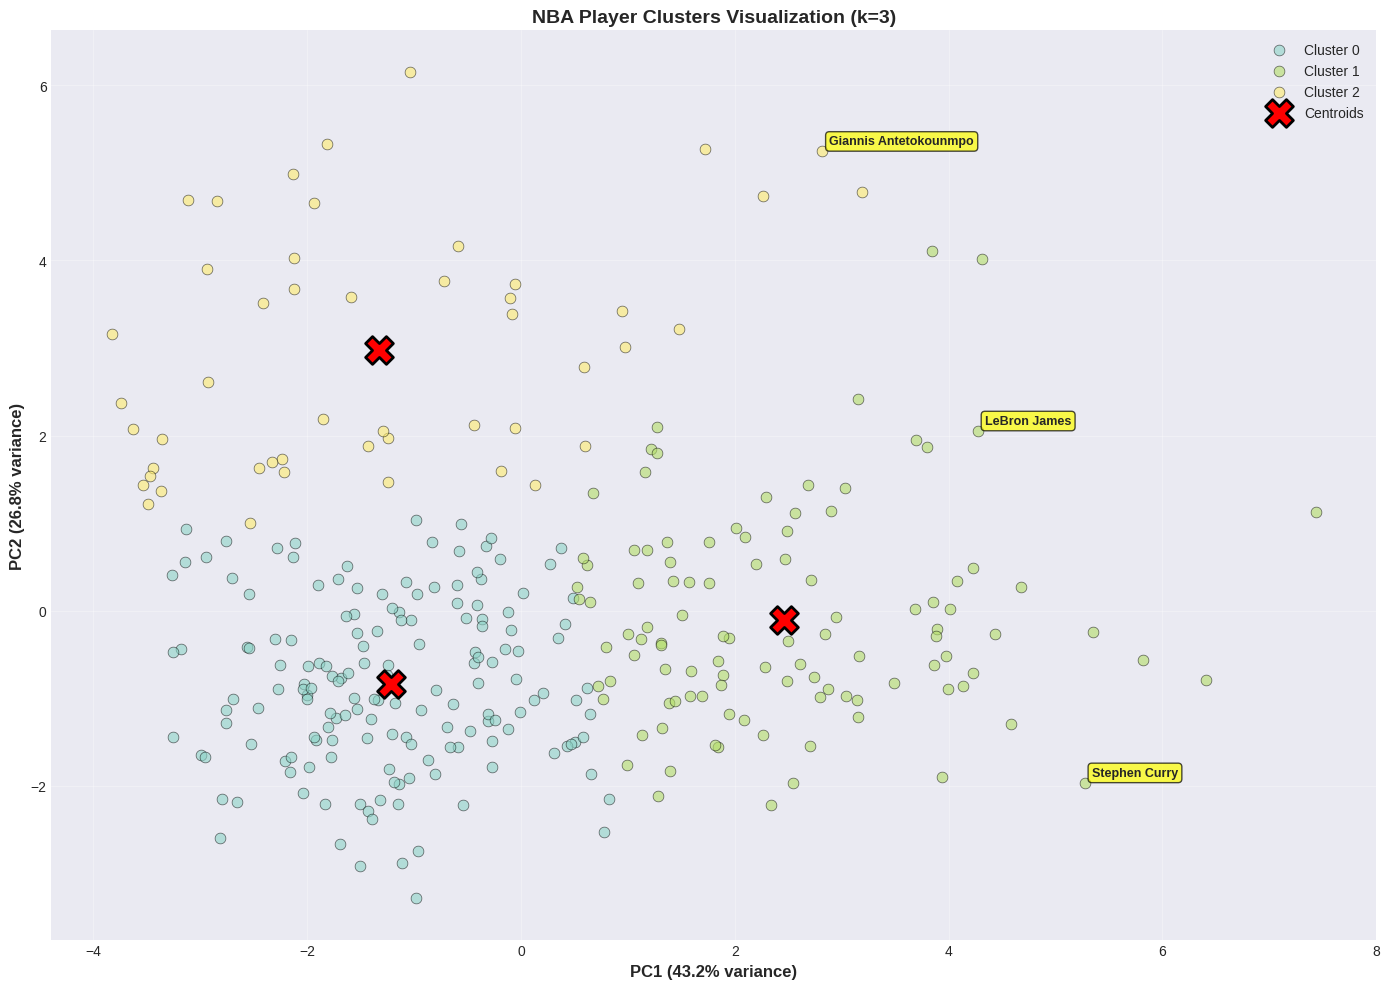

In [82]:
# Plot clusters in 2D
fig, ax = plt.subplots(figsize=(14, 10))

colors = plt.cm.Set3(np.linspace(0, 1, FINAL_K))

for cluster_id in range(FINAL_K):
    mask = cluster_labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[cluster_id]],
               label=f'Cluster {cluster_id}',
               alpha=0.6,
               s=60,
               edgecolors='black',
               linewidth=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='red', marker='X', s=400, edgecolors='black', linewidth=2,
           label='Centroids', zorder=10)

# Annotate some star players
star_players = ['LeBron James', 'Stephen Curry', 'Nikola Jokic', 'Giannis Antetokounmpo', 'Luka Doncic']
for player_name in star_players:
    if player_name in df_clean['PLAYER_NAME'].values:
        player_row = df_clean[df_clean['PLAYER_NAME'] == player_name].iloc[0]
        player_idx = df_clean[df_clean['PLAYER_NAME'] == player_name].index[0]
        original_idx = df_clean.index.get_loc(player_idx)
        ax.annotate(player_name,
                   xy=(X_pca[original_idx, 0], X_pca[original_idx, 1]),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
              fontsize=12, fontweight='bold')
ax.set_title(f'NBA Player Clusters Visualization (k={FINAL_K})',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Feature Heatmap by Cluster

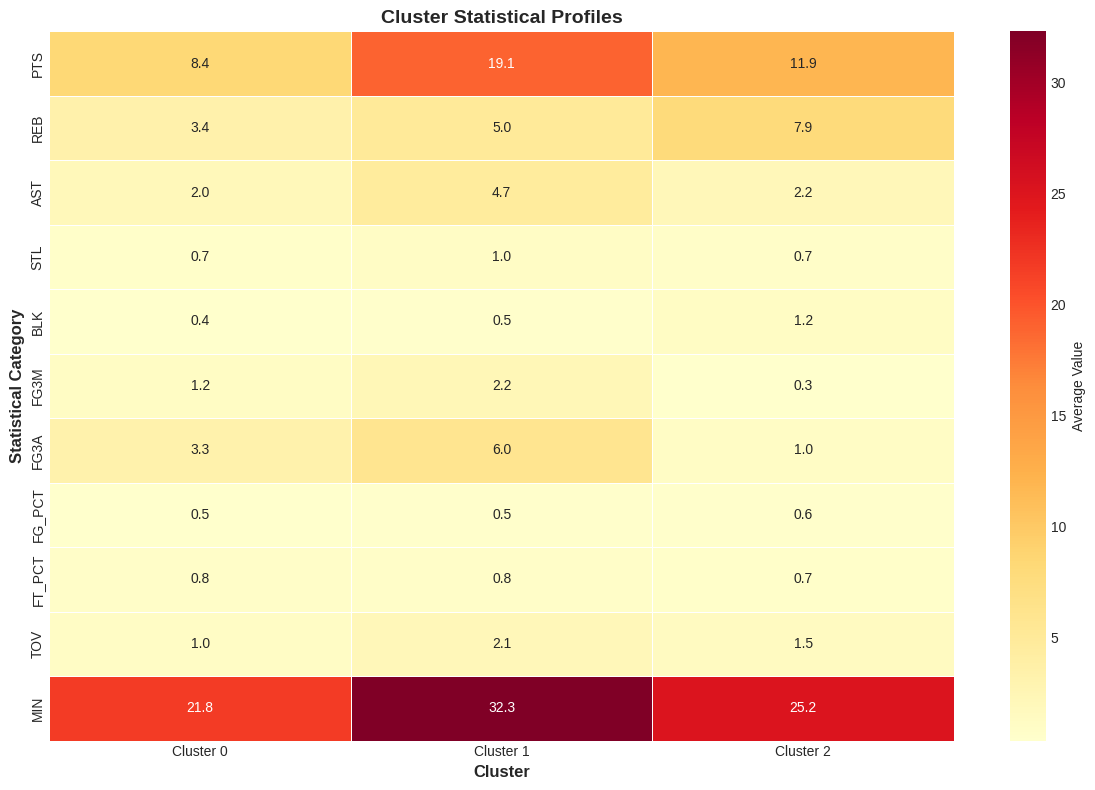

In [83]:
# Create heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(cluster_profiles.T, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Average Value'}, linewidths=0.5, ax=ax)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Statistical Category', fontsize=12, fontweight='bold')
ax.set_title('Cluster Statistical Profiles', fontsize=14, fontweight='bold')
ax.set_xticklabels([f'Cluster {i}' for i in range(FINAL_K)], rotation=0)

plt.tight_layout()
plt.show()

## Compare to Traditional Positions

In [84]:
# If we also want to see k=5 clustering (traditional positions)
if FINAL_K != 5:
    kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=20)
    labels_5 = kmeans_5.fit_predict(X_scaled)

    df_clean['cluster_k5'] = labels_5

    cluster_5_profiles = df_clean.groupby('cluster_k5')[feature_cols].mean()

    print("\nK=5 Cluster Profiles:")
    print(cluster_5_profiles.round(2))

    silhouette_5 = silhouette_score(X_scaled, labels_5)
    print(f"\nK=5 Silhouette Score: {silhouette_5:.4f}")
    print(f"Best K ({FINAL_K}) Silhouette Score: {final_silhouette:.4f}")
    print(f"\nDifference: {abs(final_silhouette - silhouette_5):.4f}")
else:
    print("\nOptimal k matches traditional 5 positions!")


K=5 Cluster Profiles:
              PTS   REB   AST   STL   BLK  FG3M  FG3A  FG_PCT  FT_PCT   TOV  \
cluster_k5                                                                    
0           13.05  4.28  3.08  0.86  0.44  1.72  4.60    0.46    0.79  1.46   
1            7.05  2.89  1.84  0.64  0.31  1.06  2.94    0.44    0.78  0.82   
2           18.82  9.75  3.88  0.94  1.38  0.85  2.45    0.55    0.76  2.25   
3           22.13  4.97  5.41  1.09  0.49  2.61  6.96    0.46    0.84  2.45   
4            8.20  6.26  1.38  0.66  0.95  0.24  0.73    0.59    0.67  0.98   

              MIN  
cluster_k5         
0           28.46  
1           19.60  
2           31.75  
3           33.93  
4           20.94  

K=5 Silhouette Score: 0.1960
Best K (3) Silhouette Score: 0.2833

Difference: 0.0874
